# Volt-VAr-Induced Curtailment Detection

Find instances where active-power curtailment is happening *because* the inverter is absorbing
reactive power (Volt-VAr response) and has run out of apparent-power headroom.

## The physics logic

An inverter rated `S_rated` kVA can deliver any combination of active power `P` and reactive
power `Q` as long as they stay inside the **apparent-power circle**: `sqrt(P² + Q²) ≤ S_rated`.

When grid voltage is high (e.g. 240 to 258 V), AS/NZS 4777.2 requires the inverter to **absorb**
reactive power. That absorption consumes part of the apparent-power "budget", so
if the irradiance is strong enough that the inverter *wants* to push out a lot of `P`, it may be
**forced to reduce `P`** to make room for the required `Q`. That reduction is labelled **Volt-VAr-induced curtailment**, distinct from Volt-Watt curtailment (which only kicks in above 253 V).

## Conditions to find Volt-VAr-induced curtailment timestamps

| # | Condition | Reason |
|---|-----------|-----|
| 1 | Clear-sky day (GHI) | so we know the inverter *could* have produced near its max |
| 2 | Peak solar window (≈11:00 to 13:00)* | when `P` is naturally highest. Most likely to hit the limit (*might be irrelevant) |
| 3 | `240 < V < 253` | V-VAr absorbing is **active** (Australia A), but V-Watt is **not yet**. Isolates the Volt-VAr effect |
| → | `sqrt(P² + Q²) ≳ S_rated` | inverter is riding its apparent-power limit |

## Two complementary tests

| Method | Uses | Answers |
|--------|------|---------|
| **A: Symptom detection** | measured P, Q, V from `ts` | *Which sites/intervals show the inverter riding its apparent-power limit while absorbing VAr?* |
| **B: Counterfactual quantification** | `all_uncurtailedpv` (GHI model) | *How many kWh of P were actually lost to VAr?* |


###  Some notes
1. **Use `S_99`, not nameplate, for the limit**: the CICCADA data pipeline normalises by `S_99`
   (99th-percentile observed apparent power), because the *effective* inverter limit in the data
   is often below the nameplate. Using nameplate could under-count curtailment.(nameplate is also pulled)
2. **Reactive sign convention.** Everything here assumes **−Q = absorbing**. If the fleet's raw
   `energy_reactive` sign is flipped, the whole detection inverts. There's a sanity-check cell.
3. **"Clear sky" needs a definition.** GHI being *high* isn't enough. It must be *stable*
   (not punching through cloud gaps). We use `GHI / GHI_clear_sky` near 1.0 **and** low local
   variance. The `structured_data` table already has `ghi` and `ghi_cs` so we use their ratio.
4. **Peak-solar window is in local time.** `t_stamp` is UTC. Convert to AEST (UTC+10) first,
   or the 11:00 to 13:00 window lands in the wrong place.
5. **Three-phase sites.** Aggregate P and Q across **all** PV circuits before computing S, and use
   `max(voltage)` across circuits (the worst phase is what triggers the VAr response).


## Before running

### 1.  `ghi` and `ghi_cs` and how they are calculated?

Both live in **`structured_data`**, the table the GHI/curtailment pipeline is built from
(`ghi_pv_estimator_general/Write_structured_data.ipynb`). Neither is a raw satellite produc. Both are derived:

- **`ghi`**: Bureau of Meteorology / NCI satellite irradiance, natively **10-minute** resolution,
  matched to each site's nearest lat/long grid cell. It is resampled to 5-minute by **duplicating**
  each 10-min reading and shifting the copy +5 minutes (not interpolated). So odd 5-minute
  intervals carry the *same* GHI value as the preceding even one. This means the practical
  temporal resolution of `ghi` is still 10 minutes, not 5.

- **`ghi_cs`** ("clear-sky GHI"): *not* a physical clear-sky model (e.g. Ineichen). It's
  **empirical**: for each site, the pipeline finds the **clearest day per month** at that
  location (lowest summed cloud-type index, `cloud_sum < 60`, peak GHI `> 200`), then for any
  given day it finds the **nearest such clear-sky day** (by calendar distance, ≤45 days). Within
  that reference day, `ghi_cs` at each 5-minute time-of-day bin is the **60th percentile of GHI**
  over a ±3-interval rolling window (`approx_percentile(GHI, 0.6) OVER (... ROWS BETWEEN 3
  PRECEDING AND 3 FOLLOWING)`), computed within continuous data segments (a gap >30 min starts a
  new segment). 
  The same logic builds `P_kw_norm_cs`, the matching clear-sky **power** shape.

So `ghi/ghi_cs` is "how much sun today, relative to the clearest day this site saw nearby in the
calendar". Not an absolute clear-sky physics model. 

This matters for you: a "clear-sky" flag near `ghi/ghi_cs ≈ 1` only means *as clear as the best recent reference day*, which might be an imperfect proxy in persistently overcast regions.


### 2. On three phase inverters

For three-phase sites, the inverter typically
responds to **per-phase** voltage, but our 240–253 V eligibility test uses `max(V)` — the worst
phase. A three-phase site could have one phase at 248 V (V-VAr-eligible) while the other two sit
at 235 V (not eligible), yet our aggregate `P` and `Q` are summed across all three. This is a
known simplification (shared with the rest of the pipeline) — it slightly overstates eligibility
for three-phase sites. If you want a cleaner read on this specific question, set
`PHASE_FILTER = "single"` to restrict to single-phase sites only, where this ambiguity doesn't
arise.


## Setup

In [23]:
import sys
from pathlib import Path

# Search the current directory and its parents for the repository root.
_current = Path.cwd().resolve()

REPO_ROOT = next(
    (
        path
        for path in (_current, *_current.parents)
        if (path / "bms_sa_review").is_dir()
    ),
    None,
)

if REPO_ROOT is None:
    raise RuntimeError(
        "Could not locate the repository root containing 'bms_sa_review'. "
        f"Current working directory: {_current}"
    )

# Support both the current package imports and legacy top-level imports
# used by some modules in this older notebook.
_IMPORT_ROOTS = (
    REPO_ROOT,
    REPO_ROOT / "bms_sa_review",
    REPO_ROOT / "bms_sa_review" / "data_query" / "lib",
)

for path in reversed(_IMPORT_ROOTS):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

print("Repository root:", REPO_ROOT)
print("Package exists:", (REPO_ROOT / "bms_sa_review").is_dir())

from bms_sa_review.shared.aws_config import aq, tables, databases

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import seaborn as sns
import pytz

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", font_scale=0.95)

Repository root: C:\Users\z3553082\OneDrive - UNSW\Documents\GitHub\CICCADA
Package exists: True


In [24]:
import subprocess
import sys
import types

from bms_sa_review.shared.ciccada_config import (
    SA,
    SAI,
    FIXED_OFFSET,
    AS4777,
    TABLES,
)

# This repository revision contains the helper-module versions expected
# by this obsolete notebook.
_LEGACY_REVISION = "901324f897d205e568e017c39b7e38fb19e16bd6"


def _load_module_from_git(module_name, repository_path):
    """Load a Python module from Git history without writing any files."""
    git_reference = f"{_LEGACY_REVISION}:{repository_path}"

    source = subprocess.check_output(
        ["git", "show", git_reference],
        cwd=str(REPO_ROOT),
    ).decode("utf-8")

    module = types.ModuleType(module_name)
    module.__file__ = f"{git_reference}"
    module.__package__ = ""

    sys.modules[module_name] = module
    exec(compile(source, module.__file__, "exec"), module.__dict__)

    return module


# The legacy modules imported ciccada_config as a top-level module.
sys.modules["ciccada_config"] = sys.modules[
    "bms_sa_review.shared.ciccada_config"
]

_legacy_queries = _load_module_from_git(
    "voltvar_queries",
    "bms_sa_review/data_query/voltvar_queries.py",
)

_legacy_metrics = _load_module_from_git(
    "voltvar_metrics",
    "bms_sa_review/data_query/voltvar_metrics.py",
)

_legacy_plots = _load_module_from_git(
    "voltvar_plots",
    "bms_sa_review/data_query/voltvar_plots.py",
)

# Query functions expected by this notebook.
fetch_method_a = _legacy_queries.fetch_method_a
fetch_method_b_site_year = _legacy_queries.fetch_method_b_site_year
fetch_day_data = _legacy_queries.fetch_day_data
fetch_eligible_context_for_year = (
    _legacy_queries.fetch_eligible_context_for_year
)
fetch_all_timestamp_context_for_year = (
    _legacy_queries.fetch_all_timestamp_context_for_year
)

# Metric functions expected by this notebook.
compute_summary_by_year = _legacy_metrics.compute_summary_by_year
compute_site_year_distribution = (
    _legacy_metrics.compute_site_year_distribution
)
compute_fleet_summary = _legacy_metrics.compute_fleet_summary
compute_site_distribution = _legacy_metrics.compute_site_distribution
compute_concentration = _legacy_metrics.compute_concentration

# Plotting functions expected by this notebook.
plot_varcurt_day = _legacy_plots.plot_varcurt_day
plot_apparent_power_circle = _legacy_plots.plot_apparent_power_circle
plot_concentration_curve = _legacy_plots.plot_concentration_curve

SD = TABLES["structured_data"]
UNC = TABLES["all_uncurtailedpv"]
T_VVAR = TABLES["conformance_voltvar"]

print("Loaded legacy helpers from Git revision:", _LEGACY_REVISION[:7])
print("Structured data:", SD)
print("Counterfactual:", UNC)
print("Volt-VAr Stage 2:", T_VVAR)

Loaded legacy helpers from Git revision: 901324f
Structured data: structured_data_v2_flex_included
Counterfactual: all_uncurtailedpv_v2_flex_included
Volt-VAr Stage 2: conformance_voltvar_v2_flex_included


In [25]:
# Check whether structured_data has been extended to 2025
# year/month are columns in structured_data (likely partition columns, so this should be a relatively cheap aggregate, but it's still a full-table group-by).
ghi_year_check = aq(f"""
    SELECT
        year,
        count(*) AS n_rows,
        count(DISTINCT site_id) AS n_sites
    FROM {SD}
    GROUP BY year
    ORDER BY year
""", database=SAI)

ghi_year_check

# If 2025 appears with a non-trivial row count, update PARAMS["GHI_YEARS"] below to [2024, 2025]

,year,n_rows,n_sites
0,2024,468078558,14417
1,2025,403576792,13254


In [26]:
# Detection parameters
PARAMS = {
    "YEARS":            [2024, 2025],  # years to scan in ts for Method A (multi-year supported)
    "GHI_YEARS":        [2024, 2025],  # years with structured_data / all_uncurtailedpv coverage
    "MAX_AC_CAPACITY_KW": 30.0,        # residential-scale systems only
    "V_LOW":            240.0,         # lower bound of V-VAr-only band
    "V_HIGH":           253.0,         # upper bound (V-Watt starts here)
    "PEAK_HOUR_START":  11,            # local (AEST) peak-solar window start
    "PEAK_HOUR_END":    14,            #   "          "            window end
    "GHI_CS_RATIO_MIN": 0.95,          # ghi/ghi_cs >= this assumes "clear enough"
                                       #   NOTE: not established elsewhere — tunable, see notes above
    "S_TOL_FRAC":       AS4777["TOL_FRAC"],   # "at the limit" tolerance, consistent with the
                                              #   4% convention used everywhere else (replaces
                                              #   the old, arbitrary S_LIMIT_FRAC=0.97)
    "USE_S99":          True,          # True: use S_99 as the apparent-power limit
                                       #   False: use ac_capacity_kw (nameplate)
    "EXCLUDE_FLEX":     True,          # True: exclude flex exports
    "PHASE_FILTER":     "all",         # "all" | "single" | "three"
                                       #   "all" matches the established 16,148-site cohort
                                       #   definition (1 inverter, up to 3 circuits)
}

print("Setup complete. Parameters:")
for k, v in PARAMS.items():
    print(f"  {k:18s} = {v}")

Setup complete. Parameters:
  YEARS              = [2024, 2025]
  GHI_YEARS          = [2024, 2025]
  MAX_AC_CAPACITY_KW = 30.0
  V_LOW              = 240.0
  V_HIGH             = 253.0
  PEAK_HOUR_START    = 11
  PEAK_HOUR_END      = 14
  GHI_CS_RATIO_MIN   = 0.95
  S_TOL_FRAC         = 0.04
  USE_S99            = True
  EXCLUDE_FLEX       = True
  PHASE_FILTER       = all


In [27]:
stage2_results = aq(f"""
    SELECT
        year,
        month,
        day_night,

        sum(nonconformance_voltvar_count)
            AS nonconformance_count,

        sum(Q_adverse_count)
            AS adverse_count,

        sum(Q_inactive_count)
            AS inactive_count,

        sum(Q_significant_shortfall_count)
            AS significant_shortfall_count,

        sum(Q_near_conformant_count)
            AS near_conformant_count,

        sum(Q_major_surplus_count)
            AS major_surplus_count,

        sum(total_count)
            AS assessable_intervals,

        sum(low_power_count)
            AS low_power_intervals,

        sum(low_power_exposed_count)
            AS low_power_exposed_intervals,

        sum(all_intervals_count)
            AS all_intervals,

        round(
            100.0 * sum(nonconformance_voltvar_count)
            / nullif(sum(total_count), 0),
            4
        ) AS nonconformance_pct_of_assessable,

        round(
            sum(curtailment_voltvar_sum)
            * {AS4777["INTERVAL_H"]},
            3
        ) AS voltvar_curtailment_kWh,

        sum(curtailment_voltvar_count)
            AS curtailment_intervals,

        sum(curtailment_eligible_count)
            AS curtailment_eligible_intervals,

        sum(null_uncurtailed_P_count)
            AS missing_counterfactual_intervals,

        sum(curtailment_eligible_count)
            - sum(null_uncurtailed_P_count)
            AS usable_counterfactual_intervals,

        round(
            100.0 * (
                sum(curtailment_eligible_count)
                - sum(null_uncurtailed_P_count)
            )
            / nullif(sum(curtailment_eligible_count), 0),
            2
        ) AS counterfactual_coverage_pct

    FROM {T_VVAR}

    GROUP BY
        year,
        month,
        day_night

    ORDER BY
        year,
        month,
        day_night
""", database=SAI)

stage2_results

,year,month,day_night,nonconformance_count,adverse_count,inactive_count,significant_shortfall_count,near_conformant_count,major_surplus_count,assessable_intervals,low_power_intervals,low_power_exposed_intervals,all_intervals,nonconformance_pct_of_assessable,voltvar_curtailment_kWh,curtailment_intervals,curtailment_eligible_intervals,missing_counterfactual_intervals,usable_counterfactual_intervals,counterfactual_coverage_pct
0,2024,1,day,17134838,3826661,9383733,1322367,466913,2135164,32078979,16135990,7975013,48214969,53.4145,24.484,1521,33258,29953,3305,9.94
1,2024,1,night,176623,34131,83700,10392,6560,41840,392825,47616227,25736322,48009052,44.9623,NaN,0,54,54,0,0.00
2,2024,2,day,16235334,3652788,8785344,1296517,473432,2027253,30278309,16625842,8312516,46904151,53.6203,11.461,1044,22175,19651,2524,11.38
3,2024,2,night,127815,23346,60541,8456,5083,30389,304589,46609567,25618308,46914156,41.9631,NaN,0,45,45,0,0.00
4,2024,3,day,17512679,3880586,9710453,1408446,518082,1995112,31328933,19405487,9940337,50734420,55.8994,4.724,397,10395,9493,902,8.68
5,2024,3,night,91262,15592,38818,5533,4457,26862,177700,50559281,29036321,50736981,51.3573,NaN,0,9,9,0,0.00
6,2024,4,day,15965915,3410451,9138652,1327992,476247,1612573,26789063,22804630,12404063,49593693,59.5986,4.609,202,3627,3167,460,12.68
7,2024,4,night,50649,8529,22070,2980,2612,14458,87673,49496880,29467411,49584553,57.7704,NaN,0,9,9,0,0.00
8,2024,5,day,13648477,2964038,7766109,1117949,415104,1385277,23712231,27509847,14185319,51222078,57.5588,5.495,62,1094,1005,89,8.14
9,2024,5,night,18831,3399,8809,1202,877,4544,30735,51212934,29893746,51243669,61.2689,NaN,0,3,3,0,0.00


## 1. Confirm the data

Data needed:
- **`ts`**: raw telemetry (P, Q, V).
- **`meta_up23c`**: `ac_capacity_kw`, `s_99`, circuit polarity, circuit count.
- **`structured_data`**: has `ghi` and `ghi_cs` (see explanation above). Confirmed 2024 only.

Run the check below. If `structured_data` is missing the `ghi` columns, we fall back to a
coarser clear-sky proxy (peak-hour window only, no irradiance check).

In [28]:
# Check structured_data schema for ghi columns
try:
    _sd = aq(f"SELECT * FROM {SD} LIMIT 1", database=SAI)
    print("structured_data columns:")
    print(list(_sd.columns))
    HAS_GHI = "ghi" in _sd.columns and "ghi_cs" in _sd.columns
    print(f"\nghi + ghi_cs present? {HAS_GHI}")
except Exception as e:
    HAS_GHI = False
    print(f"structured_data not accessible: {e}")
    print("Will fall back to measured-power clear-sky proxy.")

# Confirm meta has the capacity columns
_meta_cols = aq("SELECT * FROM meta_up23c LIMIT 1", database=SAI)
print("\nmeta_up23c has s_99?         ", "s_99" in _meta_cols.columns)
print("meta_up23c has ac_capacity_kw?", "ac_capacity_kw" in _meta_cols.columns)


structured_data columns:
['site_id', 't_stamp', 'actual_day', 'actual_tod', 'v', 'q_kvar_norm', 'p_kw_norm', 's_norm', 'ghi', 'cloud_type', 'cs_day', 'cs_tod', 'p_kw_norm_cs', 'ghi_cs', 'cloud_type_cs', 's_99', 'ac_capacity_kw', 'normalization_capacity', 'normalization_basis', 'voltage_aggregation', 'flex_selection', 'year', 'month']

ghi + ghi_cs present? True

meta_up23c has s_99?          True
meta_up23c has ac_capacity_kw? True


## 2. Method A: Fleet-wide symptom scan (`ts` + `structured_data`)

This is the **screening** query. It loops over `PARAMS["YEARS"]`, applies the clear-sky GHI
filter only for years present in `PARAMS["GHI_YEARS"]` (falling back to the peak-hour-only proxy
for the rest), and returns **candidate sites ranked by how often they show the symptom**:

> (clear sky if available) **AND** peak solar **AND** 240 < V < 253 **AND** absorbing Q
> **AND** at the apparent-power limit.

It aggregates to the **site level** (all PV circuits combined, per `PHASE_FILTER`) so three-phase
sites are handled per the convention discussed above. Results across years are concatenated and
re-aggregated to one row per site.

In [29]:
# Run across all requested years
_year_results = []
for _year in PARAMS["YEARS"]:
    _apply_ghi = HAS_GHI and (_year in PARAMS["GHI_YEARS"])
    print(f"Year {_year}: clear-sky GHI filter {'ON' if _apply_ghi else 'OFF (peak-hour proxy only)'}")
    _df = fetch_method_a(
        year=_year,
        apply_ghi_filter=_apply_ghi,
        params=PARAMS,
        has_ghi=HAS_GHI,
        aq_func=aq,
        database=SAI,
    )
    _df["year"] = _year
    _df["ghi_filtered"] = _apply_ghi
    _year_results.append(_df)

_all_years = pd.concat(_year_results, ignore_index=True)

# re-aggregate across years to one row per site
candidates = (
    _all_years.groupby("site_id")
    .agg(
        n_flagged_intervals=("n_flagged_intervals", "sum"),
        avg_V=("avg_V", "mean"),
        avg_P_kW=("avg_P_kW", "mean"),
        avg_Q_kvar=("avg_Q_kvar", "mean"),
        avg_s_limit=("avg_s_limit", "mean"),
        est_curtailed_kWh=("est_curtailed_kWh", "sum"),
        years_covered=("year", lambda s: sorted(s.unique().tolist())),
    )
    .reset_index()
    .sort_values("n_flagged_intervals", ascending=False)
)

print(f"\nSites showing Volt-VAr-curtailment symptom across {PARAMS['YEARS']}: {len(candidates)}"
      f"\nOnly considering sites with AC capacity <= {PARAMS['MAX_AC_CAPACITY_KW']} kW.")
candidates.head(20)

Year 2024: clear-sky GHI filter ON
Year 2025: clear-sky GHI filter ON

Sites showing Volt-VAr-curtailment symptom across [2024, 2025]: 7242
Only considering sites with AC capacity <= 30.0 kW.


,site_id,n_flagged_intervals,avg_V,avg_P_kW,avg_Q_kvar,avg_s_limit,est_curtailed_kWh,years_covered
930,276149647,12409,246.60,7.655,-1.750,7.89,211.46,"[2024, 2025]"
418,119401803,12296,249.05,4.780,-1.255,4.99,172.78,"[2024, 2025]"
7109,2105830595,11716,246.90,8.955,-3.970,9.89,824.75,"[2024, 2025]"
6255,1859863480,11004,248.20,4.570,-1.615,4.91,259.56,"[2024, 2025]"
2254,667745389,10849,248.75,4.450,-1.685,4.83,281.08,"[2024, 2025]"
5899,1752460611,10583,243.40,4.910,-0.475,4.99,23.55,"[2024, 2025]"
3949,1178534656,10453,244.75,4.825,-1.045,4.99,104.65,"[2024, 2025]"
132,35479265,10239,244.00,4.845,-0.515,4.92,27.15,"[2024, 2025]"
610,175225288,10141,248.00,4.675,-1.145,4.89,144.53,"[2024, 2025]"
6298,1869928836,10014,246.30,4.930,-0.020,4.96,0.02,"[2024, 2025]"


In [30]:
# TBD -> ADD THE IFs

# Run once with S_99, once with nameplate, keep both result sets
# PARAMS["USE_S99"] = True
# candidates_s99 = candidates.copy()   # after running Section 2

# PARAMS["USE_S99"] = False
# candidates_nameplate = candidates.copy()  # after running Section 2

In [31]:
'''
print(f"S_99 basis:       {len(candidates_s99):,} sites, "
      f"{candidates_s99['est_curtailed_kWh'].sum():,.0f} kWh")
print(f"Nameplate basis:  {len(candidates_nameplate):,} sites, "
      f"{candidates_nameplate['est_curtailed_kWh'].sum():,.0f} kWh")
'''

'\nprint(f"S_99 basis:       {len(candidates_s99):,} sites, "\n      f"{candidates_s99[\'est_curtailed_kWh\'].sum():,.0f} kWh")\nprint(f"Nameplate basis:  {len(candidates_nameplate):,} sites, "\n      f"{candidates_nameplate[\'est_curtailed_kWh\'].sum():,.0f} kWh")\n'

### Columns breakdown

- **`n_flagged_intervals`**: total 5-minute intervals (summed across all requested years) this
  site spent clear-sky (where available), peak-solar, in the 240~253 V band, absorbing VAr, *and*
  riding its apparent-power limit (within the 4% tolerance band). Higher = more affected.
- **`est_curtailed_kWh`**: a **first-order** estimate of energy lost, computed as the
  apparent-power headroom consumed by Q (`s_limit − sqrt(s_limit² − Q²)`) summed over flagged
  intervals. This is an upper bound (it assumes the inverter would have used all that headroom
  for P). Method B refines this with the actual clear-sky potential.
- **`years_covered`**: which of `PARAMS["YEARS"]` contributed flagged intervals for this site.
- **`avg_s_limit`**: the apparent-power limit used (`S_99` or nameplate per `PARAMS["USE_S99"]`).

Sites at the top of this list are your candidates for closer inspection.

## 3. Reactive sign convention

Everything above assumes **negative Q = absorbing**.

In the 240~253 V band the inverter is *required* to absorb, so on average across the fleet the measured Q in this band should be negative. 

**This is a fleet average, not a per-site guarantee**. Plenty of individual inverters don't comply at all (fixed power-factor units that never respond, or units running an outdated firmware). 

The check below validates the *sign convention* itself, not fleet-wide compliance. A positive *average* would mean the sign is flipped.

In [32]:
sign_check = aq(f"""
    SELECT
        round(avg(energy_reactive * circuit_polarity / 1000.0 * 12), 3) AS avg_Q_kvar_high_V,
        count(*) AS n
    FROM ts t
    JOIN (SELECT DISTINCT circuit_id, circuit_polarity
          FROM meta_up23c WHERE is_pv = True) m USING (circuit_id)
    WHERE t.year = {PARAMS['YEARS'][0]} AND t.is_pv = True
      AND t.voltage > 245 AND t.voltage < 253
""", database=SAI)

q_avg = sign_check["avg_Q_kvar_high_V"].iloc[0]
print(f"Average Q in 245~253 V band ({PARAMS['YEARS'][0]}): {q_avg} kvar")
if q_avg < 0:
    print("✓ Negative -> absorbing on average, as expected. Sign convention is correct.")
else:
    print("[!] POSITIVE -> sign may be flipped! If so, negate energy_reactive everywhere,")
    print("  OR your fleet genuinely isn't absorbing (inactive Volt-VAr) — investigate.")


Average Q in 245~253 V band (2024): -0.209 kvar
✓ Negative -> absorbing on average, as expected. Sign convention is correct.


## 4. Method B: Counterfactual quantification (uses `all_uncurtailedpv`)

Method A estimates lost energy from apparent-power headroom alone. 

Method B comparess the **clear-sky potential P** (from the GHI model, stored in `all_uncurtailedpv`)
against the **maximum P the inverter could deliver while absorbing the required Q**:

```
P_max_given_Q = sqrt(S_limit² − Q_required²)
varcurt_kW    = max(0, P_potential − P_max_given_Q)
```

If the uncurtailed potential exceeds what's possible given the VAr absorption, the difference is
VAr-induced curtailment. **Only runs for years in `PARAMS["GHI_YEARS"]`**

### How `all_uncurtailedpv` is calculated

This is the counterfactual engine behind the whole notebook.
It's a five-stage pipeline (coming from the `ghi_pv_estimator_general` folder):

1. **`Write_structured_data`** builds the per-site, per-5-min feature table: actual power
   (normalised by `S_99`, not nameplate), matched `ghi`/`ghi_cs`, and the clear-sky power shape
   `P_kw_norm_cs`.
2. **`split_days`** randomly splits each site's distinct days 80/20 into train/validation
   (day-level).
3. **`model_ghi_norm`** fits, **per site and per 5-minute time-of-day bin**, the regression:
   `P_norm/P_norm_cs = a + b × (ghi/ghi_cs)`. The intercept is **pinned**: `a = 1 − b`, so that on
   a clear-sky day (`ghi/ghi_cs = 1`) the model reproduces the clear-sky reference shape exactly.
   Training only uses clean, uncurtailed observations: `V ≤ 253` (no V-Watt) and
   `P_norm ≥ 1 OR S_norm < 1.001` (no V-VAr curtailment already happening).
4. **`Write_All_uncartailedPV`** applies the model fleet-wide to predict `P_kw_norm_est`, then
   **floors the prediction at the actual measured value** (`uncurtailed_P = max(model_prediction, actual) × S_99`), curtailment can only ever *reduce*
   output, so the counterfactual is never allowed below what was actually measured.
5. A **MAPE < 50% quality gate** (computed separately and read from a CSV of accepted site IDs)
   restricts the final table to sites where the model's accuracy is acceptable. 13,937 sites
   were fitted, with a subset passing this gate.

**Caveat worth carrying forward**: because normalisation uses `S_99` rather than nameplate, sites
that have been persistently curtailed historically have a *depressed* `S_99`, which understates
their true uncurtailed potential. the same caveat applies here as for `S_limit` in Section 0.

In [33]:
# Method B: Counterfactual quantification
# Pick the top candidate site from Method A that has data in a GHI-covered year.
# Then loop over ALL years in PARAMS["GHI_YEARS"]

_ghi_eligible = candidates[candidates["years_covered"].apply(
    lambda yrs: any(y in PARAMS["GHI_YEARS"] for y in yrs)
)]

if _ghi_eligible.empty:
    print("No candidate sites have data in a GHI-covered year. Re-run Method A "
          "with a GHI_YEARS year included in PARAMS['YEARS'].")
else:
    TARGET_SITE = int(_ghi_eligible["site_id"].iloc[0])   # change iloc[0] to pick a different site
#    TARGET_SITE = "2105830595"  # hard-coded for now, to fix...
    _limit_col  = "s_99" if PARAMS["USE_S99"] else "ac_capacity_kw"
    P = PARAMS

    varcurt_all = []

    for METHOD_B_YEAR in PARAMS["GHI_YEARS"]:
        print(f"Running Method B | site {TARGET_SITE}, year {METHOD_B_YEAR} ...")

        _df = fetch_method_b_site_year(
            year=METHOD_B_YEAR,
            site_id=TARGET_SITE,
            params=PARAMS,
            aq_func=aq,
            database=SAI,
        )

        _df["year"] = METHOD_B_YEAR
        varcurt_all.append(_df)
        print(f"  → {len(_df):,} qualifying intervals in {METHOD_B_YEAR}")

    # combine across years
    varcurt = pd.concat(varcurt_all, ignore_index=True) if varcurt_all else pd.DataFrame()

    # summary print
    if len(varcurt):
        total_intervals       = len(varcurt)
        curtailed_intervals   = (varcurt["varcurt_kW"] > 0).sum()
        no_curtail_intervals  = total_intervals - curtailed_intervals
        total_kwh             = (varcurt["varcurt_kW"] * AS4777["INTERVAL_H"]).sum()
        _years_label          = " + ".join(str(y) for y in PARAMS["GHI_YEARS"])

        print(f"\n{'='*64}")
        print(f"Method B — site {TARGET_SITE}  |  years: {_years_label}")
        print(f"{'='*64}")
        print(f"Conditions applied:")
        print(f"  Voltage band:       {P['V_LOW']:.0f}–{P['V_HIGH']:.0f} V  (V-VAr active, V-Watt not yet)")
        print(f"  Time window:        {P['PEAK_HOUR_START']}:00–{P['PEAK_HOUR_END']}:00 AEST")
        print(f"  Reactive filter:    Q < 0 (inverter actually absorbing)")
        print(f"  GHI match:          must have entry in all_uncurtailedpv (JOIN)")
        print()
        print(f"Qualifying intervals (met all conditions):       {total_intervals:,}")
        print(f"  → curtailment detected  (varcurt_kW > 0):     {curtailed_intervals:,}  "
              f"({curtailed_intervals/total_intervals*100:.1f}%)")
        print(f"  → no curtailment (Q had headroom for P):       {no_curtail_intervals:,}  "
              f"({no_curtail_intervals/total_intervals*100:.1f}%)")
        print()
        print(f"Total VAr-induced curtailment:                   {total_kwh:.2f} kWh")
        print(f"  (= energy lost because Q absorption forced P below its clear-sky potential)")

    varcurt.head(15)

Running Method B | site 276149647, year 2024 ...
  → 26,956 qualifying intervals in 2024
Running Method B | site 276149647, year 2025 ...
  → 25,404 qualifying intervals in 2025

Method B — site 276149647  |  years: 2024 + 2025
Conditions applied:
  Voltage band:       240–253 V  (V-VAr active, V-Watt not yet)
  Time window:        11:00–14:00 AEST
  Reactive filter:    Q < 0 (inverter actually absorbing)
  GHI match:          must have entry in all_uncurtailedpv (JOIN)

Qualifying intervals (met all conditions):       52,360
  → curtailment detected  (varcurt_kW > 0):     8,861  (16.9%)
  → no curtailment (Q had headroom for P):       43,499  (83.1%)

Total VAr-induced curtailment:                   85.50 kWh
  (= energy lost because Q absorption forced P below its clear-sky potential)


## 5. Visualise a day with Volt-VAr curtailment

Three power traces for a single day: **apparent power S** (the binding constraint), **active power P** (what was actually delivered), and **reactive power |Q|** (what's being absorbed). 

The violet band marks the 240~253 V eligibility window.
The red band marks intervals where curtailment was actually detected. 

This pulls a **full day** of telemetry (not just the eligible-window subset).

Plotting 2025-01-09 for site 276149647 (most curtailment events)


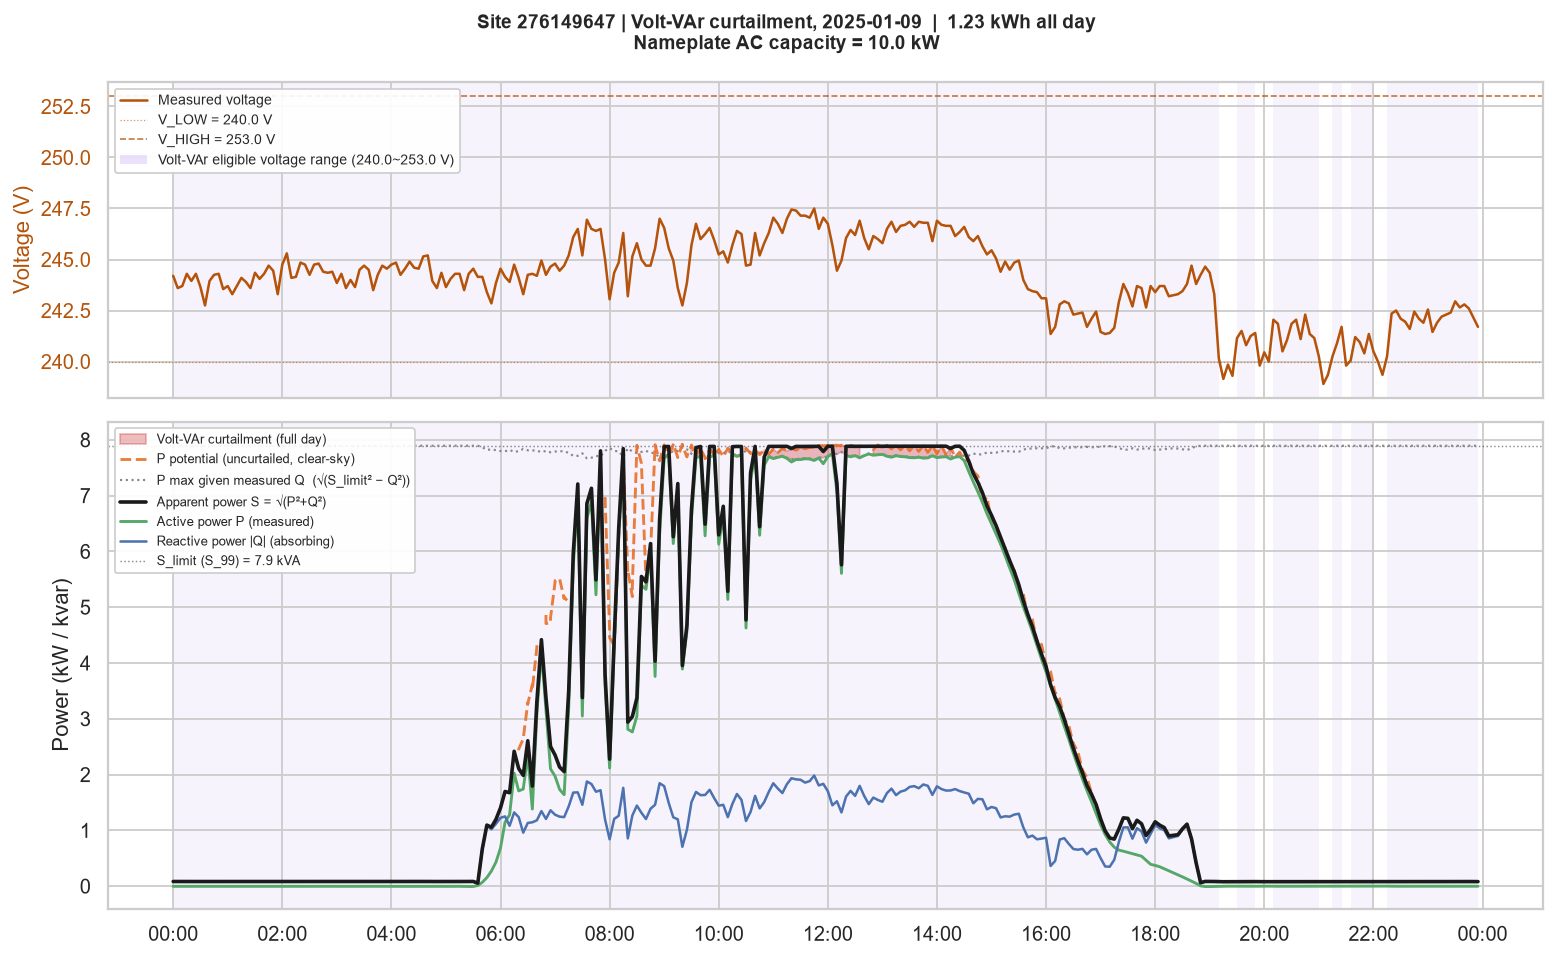

Curtailment within peak-hour window (11:00-14:00): 0.91 kWh
Curtailment across the full day:                       1.23 kWh


In [45]:
# Pick the day with the most flagged intervals for TARGET_SITE
if 'varcurt' in dir() and len(varcurt):
    varcurt["t_local"] = (pd.to_datetime(varcurt["t_stamp"])
                          .dt.tz_localize("UTC").dt.tz_convert(FIXED_OFFSET))
    best_date = (varcurt[varcurt["varcurt_kW"] > 0]
                 .groupby(varcurt["t_local"].dt.date)["varcurt_kW"]
                 .count().idxmax())
    print(f"Plotting {best_date} for site {TARGET_SITE} (most curtailment events)")

    # Fetch data, then plot (separated concerns)
    day_df = fetch_day_data(
        site_id=TARGET_SITE,
        date_str=str(best_date),
        aq_func=aq,
        database=SAI,
    )
    plot_varcurt_day(
        day_df=day_df,
        site_id=TARGET_SITE,
        date_str=str(best_date),
        ac_capacity_kw=varcurt["ac_capacity_kw"].iloc[0],
        s_limit=varcurt["s_limit"].iloc[0],
        params=PARAMS,
        restrict_to_peak_hours=False,
    )
else:
    print("Run Section 4 (Method B) first to identify a site and date with curtailment.")

## 6. Visualising one site: the apparent-power circle

Each flagged interval plotted on the **P–Q plane**, with the apparent-power circle overlaid.

Points sitting **on** the circle (within the established 4% tolerance) are highlighted with a red ring. These are the intervals where the inverter is genuinely riding its apparent-power
limit while absorbing VAr, the clearest visual signature of VAr-induced curtailment. 

Colour encodes voltage, confirming it's the high-V intervals doing it.

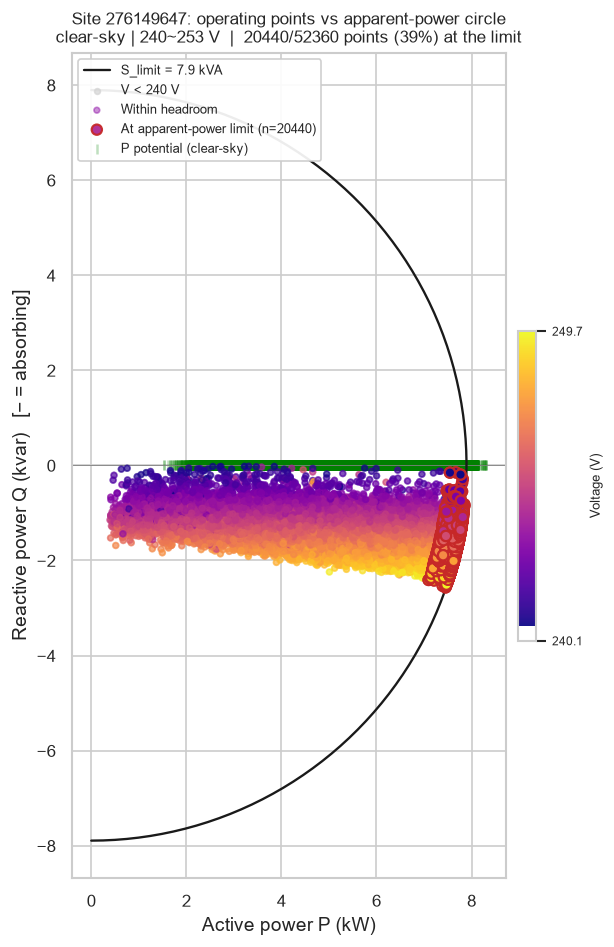

In [35]:
if 'varcurt' not in dir() or len(varcurt) == 0:
    print("No intervals to plot — run Section 4 (Method B) first.")
else:
    plot_apparent_power_circle(
        varcurt_df=varcurt,
        site_id=TARGET_SITE,
        s_limit=varcurt["s_limit"].median(),
        params=PARAMS,
    )

## 7. Fleet summary: how often does this happen, in context

 This section adds three pieces of context: 
 - the **size of the eligible fleet** (sites that ever appear in the 240~253V/peak-solar window, regardless of whether they're flagged), 
 - the**total eligible generation** in that window (from `all_uncurtailedpv`, used as the denominator for "what fraction of potential generation was lost"), and 
 - the resulting **% of sites affected** and **% of eligible generation curtailed**.

In [36]:
# Fetch denominators
_eligible_context_year_results = []
_all_context_year_results = []

for _year in PARAMS["YEARS"]:
    _apply_ghi = HAS_GHI and (_year in PARAMS["GHI_YEARS"])
    print(f"Eligible denominator year {_year}: "
          f"clear-sky GHI filter {'ON' if _apply_ghi else 'OFF (peak-hour proxy only)'}")

    _eligible_ctx = fetch_eligible_context_for_year(
        year=_year, apply_ghi_filter=_apply_ghi,
        params=PARAMS, has_ghi=HAS_GHI, aq_func=aq, database=SAI,
    )
    _eligible_ctx["year"] = _year
    _eligible_ctx["ghi_filtered"] = _apply_ghi
    _eligible_context_year_results.append(_eligible_ctx)

    print(f"All-timestamp denominator year {_year}: all observed PV timestamps")
    _all_ctx = fetch_all_timestamp_context_for_year(
        year=_year, params=PARAMS, aq_func=aq, database=SAI,
    )
    _all_ctx["year"] = _year
    _all_context_year_results.append(_all_ctx)

eligible_context_by_site_year = pd.concat(_eligible_context_year_results, ignore_index=True)
all_context_by_site_year      = pd.concat(_all_context_year_results, ignore_index=True)

# Backwards-compatible alias
fleet_context_by_site_year = eligible_context_by_site_year.copy()

Eligible denominator year 2024: clear-sky GHI filter ON
All-timestamp denominator year 2024: all observed PV timestamps
Eligible denominator year 2025: clear-sky GHI filter ON
All-timestamp denominator year 2025: all observed PV timestamps


In [37]:
# ── Compute metrics ──────────────────────────────────────────
summary_by_year = compute_summary_by_year(
    all_context_by_site_year, eligible_context_by_site_year, _all_years,
)
site_year_distribution = compute_site_year_distribution(
    all_context_by_site_year, eligible_context_by_site_year, _all_years,
)
fs = compute_fleet_summary(
    candidates, all_context_by_site_year, eligible_context_by_site_year,
)

# ── Print fleet summary ─────────────────────────────────────
if fs is None:
    print("No candidate sites found. Loosen PARAMS (e.g. raise "
          "GHI_CS_RATIO_MIN or check S_TOL_FRAC).")
else:
    print("=" * 88)
    print(f"VOLT-VAR CURTAILMENT — FLEET SUMMARY ({PARAMS['YEARS']})")
    print("=" * 88)
    print()
    print(f"Eligible case definition: peak-solar, "
          f"{PARAMS['V_LOW']:.0f}-{PARAMS['V_HIGH']:.0f} V, "
          f"same phase and limit filters as Method A")
    print()
    print("Overall multi-year denominator — all timestamps:")
    print(f"  All comparable PV sites:                 {fs['n_all_sites']:,}")
    print(f"  All observed site-intervals:             {fs['total_all_intervals']:,}")
    print(f"  All potential generation:                {fs['total_all_potential_kwh']:,.0f} kWh")
    print()
    print("Overall multi-year denominator — eligible cases only:")
    print(f"  Eligible sites:                          {fs['n_eligible_sites']:,}")
    print(f"  Eligible site-intervals:                 {fs['total_eligible_intervals']:,}")
    print(f"  Eligible potential generation:           {fs['total_eligible_potential_kwh']:,.0f} kWh")
    print()
    print("Overall multi-year numerator:")
    print(f"  Sites showing VAr-curtailment symptom:   {fs['n_sites_affected']:,} "
          f"({fs['pct_sites_affected']:.1f}% of eligible fleet)")
    print(f"  Total flagged intervals:                 {fs['total_flagged']:,}")
    print(f"  Total flagged hours:                     {fs['total_flagged_hours']:,.1f} h")
    print(f"  Share of eligible site-intervals:        {fs['pct_eligible_intervals_flagged']:.4f}%")
    print(f"  Share of all site-intervals:             {fs['pct_all_intervals_flagged']:.4f}%")
    print(f"  Est. energy curtailed, Method A:         {fs['total_est_kwh']:,.1f} kWh")
    print(f"  Avg est. curtailed power when flagged:   {fs['avg_curtailed_kw_when_flagged']:,.3f} kW")
    print(f"  Share of eligible potential generation: {fs['pct_eligible_potential_curtailed']:.4f}%")
    print(f"  Share of all potential generation:      {fs['pct_all_potential_curtailed']:.4f}%")
    print(f"  Median intervals per affected site:      {fs['median_intervals_per_affected_site']:.0f}")
    print()

    # Year-by-year breakdown
    print("=" * 88)
    print("YEAR-BY-YEAR BREAKDOWN")
    print("=" * 88)
    _display = summary_by_year.copy()
    for c in ["all_potential_kWh", "eligible_potential_kWh", "est_curtailed_kWh"]:
        _display[c] = _display[c].round(1)
    _display["pct_eligible_sites_affected"] = _display["pct_eligible_sites_affected"].round(2)
    for c in ["pct_eligible_intervals_flagged", "pct_all_intervals_flagged",
              "pct_eligible_potential_curtailed", "pct_all_potential_curtailed"]:
        _display[c] = _display[c].round(4)
    _display["avg_est_curtailed_kW_when_flagged"] = _display["avg_est_curtailed_kW_when_flagged"].round(3)
    print(_display.to_string(index=False))
    print()

    # Top 10
    print("=" * 88)
    print("TOP 10 MOST-AFFECTED SITES ACROSS ALL YEARS")
    print("=" * 88)
    top10 = candidates.sort_values("est_curtailed_kWh", ascending=False).head(10).copy()
    top10["avg_est_curtailed_kW_when_flagged"] = np.where(
        top10["n_flagged_intervals"] > 0,
        top10["est_curtailed_kWh"] / (top10["n_flagged_intervals"] * AS4777["INTERVAL_H"]),
        np.nan,
    )
    print(top10[["site_id", "n_flagged_intervals", "avg_V", "avg_P_kW",
                 "avg_Q_kvar", "est_curtailed_kWh",
                 "avg_est_curtailed_kW_when_flagged", "years_covered"
                 ]].to_string(index=False))

VOLT-VAR CURTAILMENT — FLEET SUMMARY ([2024, 2025])

Eligible case definition: peak-solar, 240-253 V, same phase and limit filters as Method A

Overall multi-year denominator — all timestamps:
  All comparable PV sites:                 15,526
  All observed site-intervals:             2,638,727,876
  All potential generation:                366,330,338 kWh

Overall multi-year denominator — eligible cases only:
  Eligible sites:                          14,694
  Eligible site-intervals:                 156,531,219
  Eligible potential generation:           60,693,496 kWh

Overall multi-year numerator:
  Sites showing VAr-curtailment symptom:   7,242 (49.3% of eligible fleet)
  Total flagged intervals:                 6,922,432
  Total flagged hours:                     576,869.3 h
  Share of eligible site-intervals:        4.4224%
  Share of all site-intervals:             0.2623%
  Est. energy curtailed, Method A:         103,117.0 kWh
  Avg est. curtailed power when flagged:   0.179 k

## 7. Fleet concnetration / Lorenz

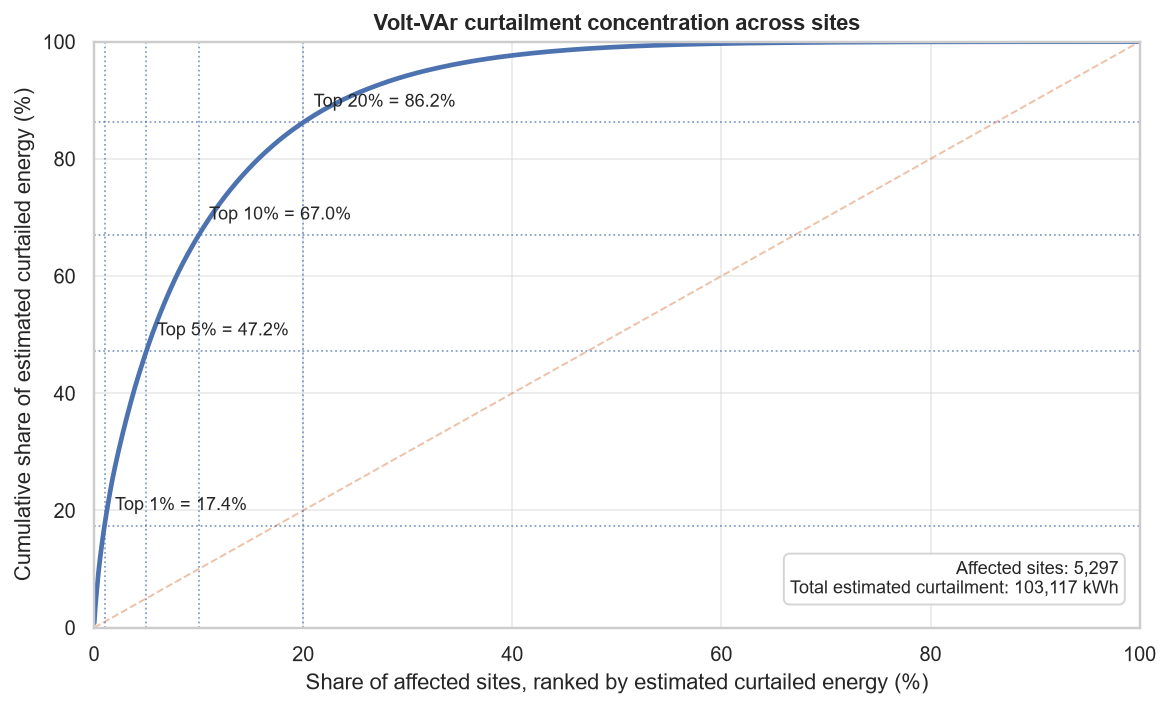


Concentration of estimated Volt-VAr curtailment:
  Top  1% of affected sites account for  17.4% of estimated curtailment
  Top  5% of affected sites account for  47.2% of estimated curtailment
  Top 10% of affected sites account for  67.0% of estimated curtailment
  Top 20% of affected sites account for  86.2% of estimated curtailment

Total affected sites: 5,297
Total estimated curtailment: 103,117.0 kWh


In [38]:
# Site-level distribution + concentration
site_dist = compute_site_distribution(
    candidates, eligible_context_by_site_year, all_context_by_site_year,
)

curt_rank, concentration, total_curt_kWh = compute_concentration(site_dist, percentiles=(1, 5, 10, 20))

# Plot
plot_concentration_curve(curt_rank, concentration, total_curt_kWh)

# Summary
if concentration:
    print("\nConcentration of estimated Volt-VAr curtailment:")
    for pct_sites, share in concentration.items():
        print(f"  Top {pct_sites:>2}% of affected sites account for "
              f"{share:5.1f}% of estimated curtailment")
    print(f"\nTotal affected sites: {len(curt_rank):,}")
    print(f"Total estimated curtailment: {total_curt_kWh:,.1f} kWh")

In [39]:
site_dist.sort_values("pct_all_potential_curtailed", ascending=False)

,site_id,all_intervals,all_potential_kWh,eligible_intervals,eligible_potential_kWh,flagged_intervals,est_curtailed_kWh,flagged_hours,affected,pct_eligible_timestamps_flagged,pct_all_timestamps_flagged,pct_eligible_potential_curtailed,pct_all_potential_curtailed,avg_est_curtailed_kW_when_flagged
12281,1702915042,9756,136.740,135,37.642,60,5.63,5.0,True,44.444444,0.615006,14.956697,4.117303,1.126000
14082,1946651728,94621,3885.430,6264,792.225,991,101.76,82.583333,True,15.820562,1.047336,12.844836,2.619015,1.232210
8528,1186659235,40058,2919.122,3719,816.007,2689,75.02,224.083333,True,72.304383,6.712766,9.193549,2.569951,0.334786
9323,1296163246,32783,3668.759,984,394.524,826,78.91,68.833333,True,83.943089,2.519599,20.001318,2.150864,1.146392
12043,1671431210,24687,1856.301,1576,419.068,934,38.81,77.833333,True,59.263959,3.783368,9.261027,2.090717,0.498630
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15394,2126196917,3272,0.000,0,0.000,0,0.00,0.0,False,NaN,0.000000,NaN,NaN,NaN
15452,2136215128,1798,0.000,236,0.000,16,0.19,1.333333,True,6.779661,0.889878,NaN,NaN,0.142500
15478,2139519699,125442,0.000,0,0.000,0,0.00,0.0,False,NaN,0.000000,NaN,NaN,NaN
15490,2141726171,314,0.000,6,0.000,0,0.00,0.0,False,0.000000,0.000000,NaN,NaN,NaN


## 9. Fleet summary viz

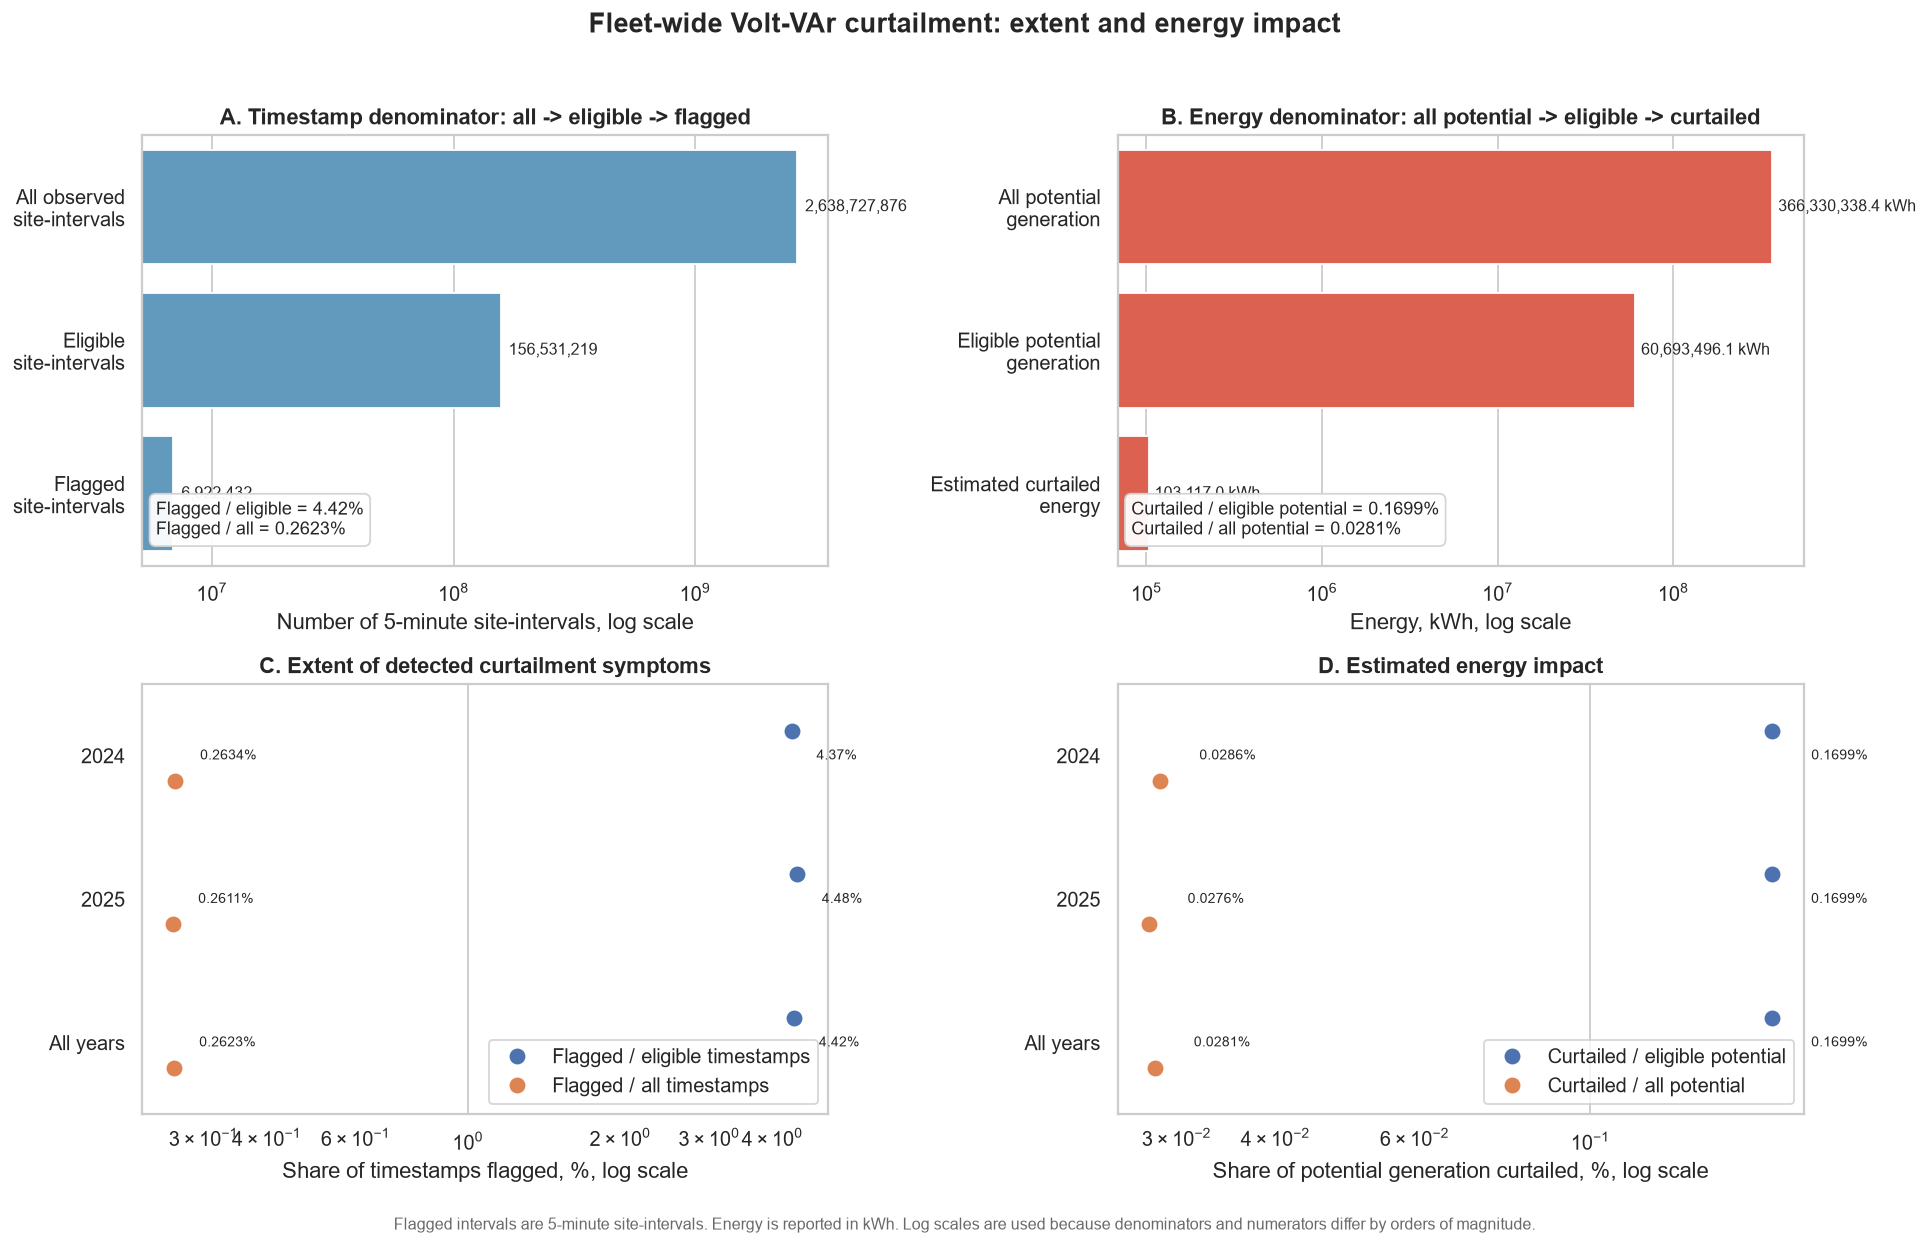

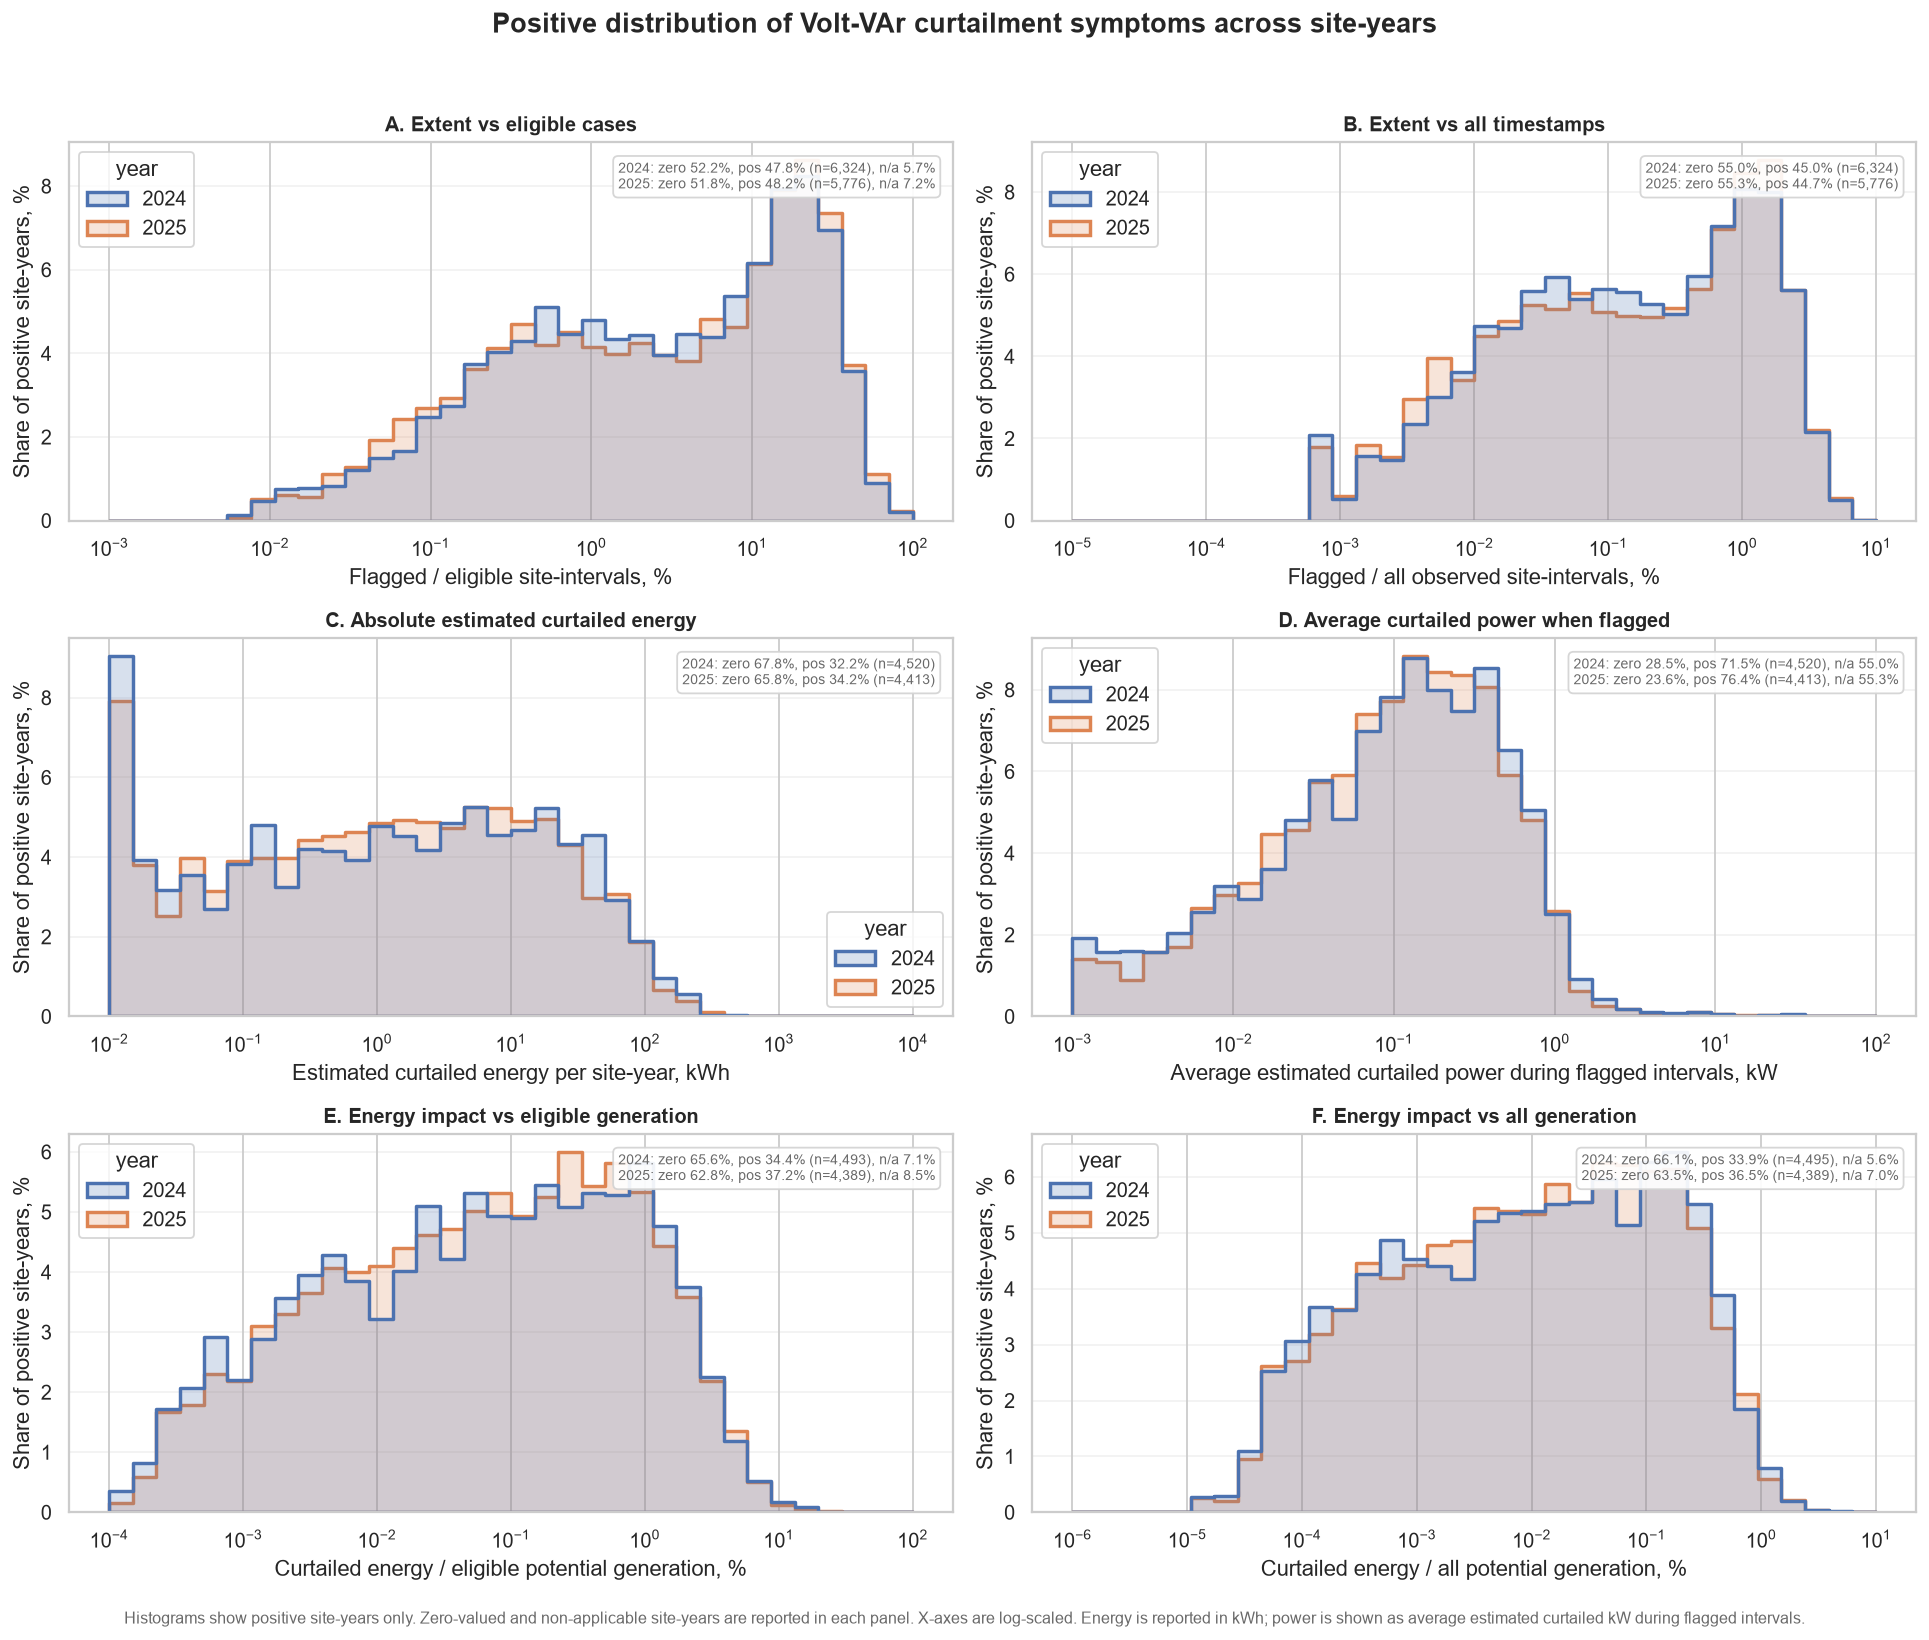

In [40]:
# =============================================================================
# VISUALISATION — CLEAN FLEET SUMMARY + POSITIVE-VALUE DISTRIBUTIONS
#
# Produces:
#   Figure 1: Compact fleet-level denominator summary
#   Figure 2: Positive-value distribution histograms
#
# Removes the previous percentile/range Figure 2.
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")


# -------------------------------------------------------------------------
# Helper formatting
# -------------------------------------------------------------------------

def _fmt_num(x, decimals=1):
    if pd.isna(x):
        return "n/a"
    if abs(x) >= 1_000_000:
        return f"{x/1_000_000:.{decimals}f}M"
    if abs(x) >= 1_000:
        return f"{x/1_000:.{decimals}f}k"
    if abs(x) >= 10:
        return f"{x:,.0f}"
    if abs(x) >= 1:
        return f"{x:,.1f}"
    if abs(x) >= 0.01:
        return f"{x:,.3f}"
    return f"{x:,.5f}"


def _fmt_pct(x, decimals=4):
    if pd.isna(x):
        return "n/a"
    if abs(x) >= 10:
        return f"{x:.1f}%"
    if abs(x) >= 1:
        return f"{x:.2f}%"
    return f"{x:.{decimals}f}%"


# -------------------------------------------------------------------------
# Build overall summary row for plotting
# -------------------------------------------------------------------------

overall_summary = pd.DataFrame([{
    "year": "All years",
    "all_sites": all_context_by_site_year["site_id"].nunique(),
    "all_intervals": all_context_by_site_year["n_all_intervals"].sum(),
    "all_potential_kWh": all_context_by_site_year["all_potential_kWh"].sum(),
    "eligible_sites": eligible_context_by_site_year["site_id"].nunique(),
    "eligible_intervals": eligible_context_by_site_year["n_eligible_intervals"].sum(),
    "eligible_potential_kWh": eligible_context_by_site_year["eligible_potential_kWh"].sum(),
    "affected_sites": candidates["site_id"].nunique(),
    "flagged_intervals": candidates["n_flagged_intervals"].sum(),
    "est_curtailed_kWh": candidates["est_curtailed_kWh"].sum()
}])

overall_summary["pct_eligible_intervals_flagged"] = np.where(
    overall_summary["eligible_intervals"] > 0,
    overall_summary["flagged_intervals"] / overall_summary["eligible_intervals"] * 100,
    np.nan
)

overall_summary["pct_all_intervals_flagged"] = np.where(
    overall_summary["all_intervals"] > 0,
    overall_summary["flagged_intervals"] / overall_summary["all_intervals"] * 100,
    np.nan
)

overall_summary["pct_eligible_potential_curtailed"] = np.where(
    overall_summary["eligible_potential_kWh"] > 0,
    overall_summary["est_curtailed_kWh"] / overall_summary["eligible_potential_kWh"] * 100,
    np.nan
)

overall_summary["pct_all_potential_curtailed"] = np.where(
    overall_summary["all_potential_kWh"] > 0,
    overall_summary["est_curtailed_kWh"] / overall_summary["all_potential_kWh"] * 100,
    np.nan
)

overall_summary["avg_est_curtailed_kW_when_flagged"] = np.where(
    overall_summary["flagged_intervals"] > 0,
    overall_summary["est_curtailed_kWh"] /
    (overall_summary["flagged_intervals"] * AS4777["INTERVAL_H"]),
    np.nan
)

summary_plot_df = pd.concat(
    [
        summary_by_year.assign(year=summary_by_year["year"].astype(str)),
        overall_summary
    ],
    ignore_index=True
)


# =============================================================================
# FIGURE 1 — CLEAN FLEET-LEVEL DENOMINATOR SUMMARY
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 9), dpi=130)

# -------------------------------------------------------------------------
# A. Timestamp denominator funnel
# -------------------------------------------------------------------------

ax = axes[0, 0]

timestamp_values = pd.DataFrame({
    "category": [
        "All observed\nsite-intervals",
        "Eligible\nsite-intervals",
        "Flagged\nsite-intervals"
    ],
    "value": [
        overall_summary["all_intervals"].iloc[0],
        overall_summary["eligible_intervals"].iloc[0],
        overall_summary["flagged_intervals"].iloc[0]
    ]
})

sns.barplot(
    data=timestamp_values,
    y="category",
    x="value",
    orient="h",
    color=sns.color_palette("Blues")[3],
    ax=ax
)

ax.set_xscale("log")
ax.set_xlabel("Number of 5-minute site-intervals, log scale")
ax.set_ylabel("")
ax.set_title("A. Timestamp denominator: all -> eligible -> flagged", weight="bold")

for i, r in timestamp_values.iterrows():
    ax.text(
        r["value"] * 1.08,
        i,
        f"{r['value']:,.0f}",
        va="center",
        fontsize=9
    )

ax.text(
    0.02,
    0.06,
    f"Flagged / eligible = {_fmt_pct(overall_summary['pct_eligible_intervals_flagged'].iloc[0])}\n"
    f"Flagged / all = {_fmt_pct(overall_summary['pct_all_intervals_flagged'].iloc[0])}",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=10,
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="lightgrey",
        alpha=0.95
    )
)

# -------------------------------------------------------------------------
# B. Energy denominator funnel
# -------------------------------------------------------------------------

ax = axes[0, 1]

energy_values = pd.DataFrame({
    "category": [
        "All potential\ngeneration",
        "Eligible potential\ngeneration",
        "Estimated curtailed\nenergy"
    ],
    "value": [
        overall_summary["all_potential_kWh"].iloc[0],
        overall_summary["eligible_potential_kWh"].iloc[0],
        overall_summary["est_curtailed_kWh"].iloc[0]
    ]
})

sns.barplot(
    data=energy_values,
    y="category",
    x="value",
    orient="h",
    color=sns.color_palette("Reds")[3],
    ax=ax
)

ax.set_xscale("log")
ax.set_xlabel("Energy, kWh, log scale")
ax.set_ylabel("")
ax.set_title("B. Energy denominator: all potential -> eligible -> curtailed", weight="bold")

for i, r in energy_values.iterrows():
    ax.text(
        r["value"] * 1.08,
        i,
        f"{r['value']:,.1f} kWh",
        va="center",
        fontsize=9
    )

ax.text(
    0.02,
    0.06,
    f"Curtailed / eligible potential = {_fmt_pct(overall_summary['pct_eligible_potential_curtailed'].iloc[0])}\n"
    f"Curtailed / all potential = {_fmt_pct(overall_summary['pct_all_potential_curtailed'].iloc[0])}",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=10,
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="lightgrey",
        alpha=0.95
    )
)

# -------------------------------------------------------------------------
# C. Year-by-year timestamp rates
# -------------------------------------------------------------------------

ax = axes[1, 0]

rate_df = (
    summary_plot_df[[
        "year",
        "pct_eligible_intervals_flagged",
        "pct_all_intervals_flagged"
    ]]
    .melt(
        id_vars="year",
        var_name="metric",
        value_name="percent"
    )
)

rate_df["metric"] = rate_df["metric"].map({
    "pct_eligible_intervals_flagged": "Flagged / eligible timestamps",
    "pct_all_intervals_flagged": "Flagged / all timestamps"
})

sns.pointplot(
    data=rate_df,
    x="percent",
    y="year",
    hue="metric",
    dodge=0.35,
    markers="o",
    linestyles="",
    ax=ax
)

ax.set_xscale("log")
ax.set_xlabel("Share of timestamps flagged, %, log scale")
ax.set_ylabel("")
ax.set_title("C. Extent of detected curtailment symptoms", weight="bold")
ax.legend(title="", loc="lower right", frameon=True)

for _, r in rate_df.iterrows():
    if pd.notna(r["percent"]) and r["percent"] > 0:
        ax.text(
            r["percent"] * 1.12,
            list(summary_plot_df["year"]).index(r["year"]),
            _fmt_pct(r["percent"]),
            va="center",
            fontsize=8
        )

# -------------------------------------------------------------------------
# D. Year-by-year energy rates
# -------------------------------------------------------------------------

ax = axes[1, 1]

energy_rate_df = (
    summary_plot_df[[
        "year",
        "pct_eligible_potential_curtailed",
        "pct_all_potential_curtailed"
    ]]
    .melt(
        id_vars="year",
        var_name="metric",
        value_name="percent"
    )
)

energy_rate_df["metric"] = energy_rate_df["metric"].map({
    "pct_eligible_potential_curtailed": "Curtailed / eligible potential",
    "pct_all_potential_curtailed": "Curtailed / all potential"
})

sns.pointplot(
    data=energy_rate_df,
    x="percent",
    y="year",
    hue="metric",
    dodge=0.35,
    markers="o",
    linestyles="",
    ax=ax
)

ax.set_xscale("log")
ax.set_xlabel("Share of potential generation curtailed, %, log scale")
ax.set_ylabel("")
ax.set_title("D. Estimated energy impact", weight="bold")
ax.legend(title="", loc="lower right", frameon=True)

for _, r in energy_rate_df.iterrows():
    if pd.notna(r["percent"]) and r["percent"] > 0:
        ax.text(
            r["percent"] * 1.12,
            list(summary_plot_df["year"]).index(r["year"]),
            _fmt_pct(r["percent"]),
            va="center",
            fontsize=8
        )

fig.suptitle(
    "Fleet-wide Volt-VAr curtailment: extent and energy impact",
    fontsize=15,
    weight="bold",
    y=1.02
)

fig.text(
    0.5,
    -0.01,
    "Flagged intervals are 5-minute site-intervals. Energy is reported in kWh. "
    "Log scales are used because denominators and numerators differ by orders of magnitude.",
    ha="center",
    va="top",
    fontsize=9,
    color="dimgray"
)

plt.tight_layout()
plt.show()


# =============================================================================
# FIGURE 2 — POSITIVE-VALUE DISTRIBUTIONS
#
# Histograms show positive site-years only.
# Zero-valued and non-applicable site-years are reported in each annotation.
#
# This replaces the previous percentile/range Figure 2.
# =============================================================================

plot_df = site_year_distribution.copy().reset_index(drop=True)
plot_df["year"] = plot_df["year"].astype(str)

# Defensive renaming/aliasing in case older notebook versions still have
# pct_potential_generation_curtailed rather than the new eligible/all names.
if (
    "pct_eligible_potential_generation_curtailed" not in plot_df.columns
    and "pct_potential_generation_curtailed" in plot_df.columns
):
    plot_df["pct_eligible_potential_generation_curtailed"] = (
        plot_df["pct_potential_generation_curtailed"]
    )

# Main distribution metrics requested
distribution_metrics = {
    "pct_eligible_timestamps_flagged": {
        "title": "A. Extent vs eligible cases",
        "xlabel": "Flagged / eligible site-intervals, %",
        "bins": np.logspace(-3, 2, 35),
        "denominator_col": "n_eligible_intervals"
    },
    "pct_all_timestamps_flagged": {
        "title": "B. Extent vs all timestamps",
        "xlabel": "Flagged / all observed site-intervals, %",
        "bins": np.logspace(-5, 1, 35),
        "denominator_col": "n_all_intervals"
    },
    "est_curtailed_kWh": {
        "title": "C. Absolute estimated curtailed energy",
        "xlabel": "Estimated curtailed energy per site-year, kWh",
        "bins": np.logspace(-2, 4, 35),
        "denominator_col": "n_all_intervals"
    },
    "avg_est_curtailed_kW_when_flagged": {
        "title": "D. Average curtailed power when flagged",
        "xlabel": "Average estimated curtailed power during flagged intervals, kW",
        "bins": np.logspace(-3, 2, 35),
        "denominator_col": "n_flagged_intervals"
    },
    "pct_eligible_potential_generation_curtailed": {
        "title": "E. Energy impact vs eligible generation",
        "xlabel": "Curtailed energy / eligible potential generation, %",
        "bins": np.logspace(-4, 2, 35),
        "denominator_col": "eligible_potential_kWh"
    },
    "pct_all_potential_generation_curtailed": {
        "title": "F. Energy impact vs all generation",
        "xlabel": "Curtailed energy / all potential generation, %",
        "bins": np.logspace(-6, 1, 35),
        "denominator_col": "all_potential_kWh"
    }
}


def _plot_positive_hist_panel(
    ax,
    df,
    value_col,
    title,
    xlabel,
    bins,
    denominator_col=None
):
    local_df = df.copy()

    if denominator_col is not None and denominator_col in local_df.columns:
        applicable_mask = local_df[denominator_col].fillna(0) > 0
    else:
        applicable_mask = pd.Series(True, index=local_df.index)

    applicable_df = local_df[applicable_mask].copy()
    positive_df = applicable_df[applicable_df[value_col].fillna(0) > 0].copy()

    if positive_df.empty:
        ax.set_title(title, fontsize=11, weight="bold")
        ax.text(
            0.5,
            0.5,
            "No positive values",
            ha="center",
            va="center"
        )
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Share of positive site-years, %")
        return

    sns.histplot(
        data=positive_df,
        x=value_col,
        hue="year",
        bins=bins,
        element="step",
        stat="percent",
        common_norm=False,
        fill=True,
        alpha=0.22,
        linewidth=1.9,
        ax=ax
    )

    ax.set_xscale("log")
    ax.set_title(title, fontsize=11, weight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Share of positive site-years, %")
    ax.grid(axis="y", alpha=0.25)

    annotation_lines = []

    for year, g in local_df.groupby("year"):
        if denominator_col is not None and denominator_col in g.columns:
            applicable = g[g[denominator_col].fillna(0) > 0].copy()
            n_not_applicable = len(g) - len(applicable)
        else:
            applicable = g.copy()
            n_not_applicable = 0

        values = applicable[value_col].fillna(0)

        n_applicable = len(applicable)
        n_pos = int((values > 0).sum())
        n_zero = int((values == 0).sum())

        zero_share = n_zero / n_applicable * 100 if n_applicable > 0 else np.nan
        positive_share = n_pos / n_applicable * 100 if n_applicable > 0 else np.nan
        na_share = n_not_applicable / len(g) * 100 if len(g) > 0 else np.nan

        if n_applicable > 0:
            annotation_lines.append(
                f"{year}: zero {zero_share:.1f}%, pos {positive_share:.1f}% (n={n_pos:,})"
            )
        else:
            annotation_lines.append(
                f"{year}: no applicable site-years"
            )

        if n_not_applicable > 0:
            annotation_lines[-1] += f", n/a {na_share:.1f}%"

    ax.text(
        0.98,
        0.95,
        "\n".join(annotation_lines),
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=8,
        color="dimgray",
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            edgecolor="lightgrey",
            alpha=0.92
        )
    )


fig, axes = plt.subplots(3, 2, figsize=(15, 12), dpi=130)
axes = axes.flatten()

for ax, (value_col, cfg) in zip(axes, distribution_metrics.items()):
    _plot_positive_hist_panel(
        ax=ax,
        df=plot_df,
        value_col=value_col,
        title=cfg["title"],
        xlabel=cfg["xlabel"],
        bins=cfg["bins"],
        denominator_col=cfg["denominator_col"]
    )

fig.suptitle(
    "Positive distribution of Volt-VAr curtailment symptoms across site-years",
    fontsize=15,
    weight="bold",
    y=1.02
)

fig.text(
    0.5,
    -0.005,
    "Histograms show positive site-years only. Zero-valued and non-applicable site-years are reported in each panel. "
    "X-axes are log-scaled. Energy is reported in kWh; power is shown as average estimated curtailed kW during flagged intervals.",
    ha="center",
    va="top",
    fontsize=9,
    color="dimgray"
)

plt.tight_layout()
plt.show()

## 10. Notes, caveats, and next steps

**What changed from the previous version**: replaced the arbitrary `S_LIMIT_FRAC=0.97` with
`S_TOL_FRAC` tied to the established 4% AC-capacity tolerance convention; clarified that
`GHI_CS_RATIO_MIN=0.85` has no precedent elsewhere and is tunable; added multi-year support
(`PARAMS["YEARS"]` vs `PARAMS["GHI_YEARS"]`); added a `PHASE_FILTER` toggle (default: include
both single- and three-phase, matching the established cohort convention); fixed `ghi`/`ghi_cs`
casing; added fleet-wide compliance-by-voltage visualisations, a full-day 3-power-line plot with
curtailment shading, an improved apparent-power-circle plot with on-limit highlighting, and
fleet-context denominators in the summary section.

**Caveats to keep in mind**

1. **`S_99` vs nameplate** — `S_99` is the empirical limit and usually the right choice, but for
   sites that have been curtailing for most of their history, `S_99` is itself depressed, which
   *under*-counts curtailment. Toggle `USE_S99` to compare.
2. **GHI/`all_uncurtailedpv` coverage is `PARAMS["GHI_YEARS"]` only** (currently `[2024]`) — Method
   B and the fleet-context denominator can't run for years outside this list.
3. **`GHI_CS_RATIO_MIN` and `S_TOL_FRAC` are tunable, not derived from the standard** — run a
   sensitivity sweep before quoting a headline number.
4. **The 240–253 V band deliberately excludes the 253–258 V overlap zone** where V-VAr and
   V-Watt act together — in the overlap you can't cleanly attribute curtailment to VAr alone.
5. **Three-phase sites use `max(V)` for eligibility but sum P/Q across phases** — see the phase
   discussion above; set `PHASE_FILTER="single"` if this ambiguity matters for your analysis.
6. **`ghi_cs` is an empirical nearest-clear-sky-day reference, not a physical clear-sky model** —
   it inherits whatever shading/soiling/noise was present on that specific reference day.

**Suggested next steps**

- Run Method A with `USE_S99=True` and `False`; report the range.
- Sensitivity-check `GHI_CS_RATIO_MIN` at 0.80 / 0.85 / 0.90 and confirm the candidate site list
  is stable.
- Cross-tabulate affected sites by **DNSP** and **OEM** — some inverter brands default to
  fixed-PF and won't show this symptom at all, which is itself a finding worth reporting.
- Compare the Volt-VAr-curtailment site list against the Volt-Watt-curtailment list: sites doing
  *both* are losing the most generation at high voltage.


## 11. Data filter

In [41]:
# ── Fleet funnel diagnostic: trace exactly how many sites survive each filter ─
# Notes this is looking at the year of interest (first GHI year) only, and is not a multi-year summary. Need to run for multiple years if needed.
_ctx_year   = PARAMS["GHI_YEARS"][0]
_limit_col  = "s_99" if PARAMS["USE_S99"] else "ac_capacity_kw"

print("Running funnel diagnostic — 4 separate Athena queries...")

# Step 0: every site with at least one PV circuit
step0 = aq(f"""
    SELECT count(DISTINCT site_id) AS n
    FROM meta_up23c
    WHERE is_pv = True
      AND ac_capacity_kw > 0
      AND ac_capacity_kw <= {PARAMS['MAX_AC_CAPACITY_KW']}
""", database=SAI)

# Step 1: + valid apparent-power limit (s_99 or ac_capacity_kw > 0)
step1 = aq(f"""
    SELECT count(DISTINCT site_id) AS n
    FROM meta_up23c
    WHERE is_pv = True
      AND {_limit_col} > 0
      AND ac_capacity_kw > 0
      AND ac_capacity_kw <= {PARAMS['MAX_AC_CAPACITY_KW']}
""", database=SAI)

# Step 2: + at least one 5-min interval in the 240-253V band, this year
step2 = aq(f"""
    SELECT count(DISTINCT sm.site_id) AS n
    FROM ts t
    JOIN (SELECT DISTINCT site_id, circuit_id FROM meta_up23c
            WHERE is_pv = True
            AND {_limit_col} > 0
            AND ac_capacity_kw > 0
            AND ac_capacity_kw <= {PARAMS['MAX_AC_CAPACITY_KW']}) sm
      ON t.circuit_id = sm.circuit_id
    WHERE t.year = {_ctx_year} AND t.is_pv = True
      AND t.voltage > {PARAMS['V_LOW']} AND t.voltage < {PARAMS['V_HIGH']}
""", database=SAI)

# Step 3: + also within the peak-solar window (11:00-13:00 AEST)
step3 = aq(f"""
    SELECT count(DISTINCT sm.site_id) AS n
    FROM ts t
    JOIN (SELECT DISTINCT site_id, circuit_id FROM meta_up23c
          WHERE is_pv = True
            AND {_limit_col} > 0
            AND ac_capacity_kw > 0
            AND ac_capacity_kw <= {PARAMS['MAX_AC_CAPACITY_KW']}) sm
      ON t.circuit_id = sm.circuit_id
    WHERE t.year = {_ctx_year} AND t.is_pv = True
      AND t.voltage > {PARAMS['V_LOW']} AND t.voltage < {PARAMS['V_HIGH']}
      AND hour(t.t_stamp + interval '10' hour)
          BETWEEN {PARAMS['PEAK_HOUR_START']} AND {PARAMS['PEAK_HOUR_END']}
""", database=SAI)

# Step 4: + also clear-sky (ghi/ghi_cs >= GHI_CS_RATIO_MIN) — this is n_eligible_sites
step4 = aq(f"""
    SELECT count(DISTINCT sm.site_id) AS n
    FROM ts t
    JOIN (SELECT DISTINCT site_id, circuit_id FROM meta_up23c
          WHERE is_pv = True AND {_limit_col} > 0) sm
      ON t.circuit_id = sm.circuit_id
    JOIN {SD} sd
      ON sm.site_id = sd.site_id AND t.t_stamp = sd.t_stamp
    WHERE t.year = {_ctx_year} AND t.is_pv = True
      AND t.voltage > {PARAMS['V_LOW']} AND t.voltage < {PARAMS['V_HIGH']}
      AND hour(t.t_stamp + interval '10' hour)
          BETWEEN {PARAMS['PEAK_HOUR_START']} AND {PARAMS['PEAK_HOUR_END']}
      AND sd.ghi_cs > 0 AND sd.ghi / sd.ghi_cs >= {PARAMS['GHI_CS_RATIO_MIN']}
""", database=SAI)

funnel = pd.DataFrame({
    "stage": [
        "0. All is_pv sites",
        f"1. + valid {_limit_col}",
        f"2. + any 5-min interval {PARAMS['V_LOW']:.0f}-{PARAMS['V_HIGH']:.0f}V ({_ctx_year})",
        f"3. + within peak-solar window ({PARAMS['PEAK_HOUR_START']}:00-{PARAMS['PEAK_HOUR_END']}:00)",
        f"4. + clear-sky (ghi/ghi_cs >= {PARAMS['GHI_CS_RATIO_MIN']})",
    ],
    "n_sites": [step0["n"].iloc[0], step1["n"].iloc[0], step2["n"].iloc[0],
               step3["n"].iloc[0], step4["n"].iloc[0]],
})
funnel["pct_of_start"] = (funnel["n_sites"] / funnel["n_sites"].iloc[0] * 100).round(1)
funnel["dropped_this_step"] = funnel["n_sites"].diff().fillna(0).astype(int).abs()

print(funnel.to_string(index=False))
print(f"\nFinal n_eligible_sites (step 4) should match the fleet_context query: "
      f"{funnel['n_sites'].iloc[-1]:,}")

Running funnel diagnostic — 4 separate Athena queries...
                                      stage  n_sites  pct_of_start  dropped_this_step
                         0. All is_pv sites    15526         100.0                  0
                            1. + valid s_99    15526         100.0                  0
    2. + any 5-min interval 240-253V (2024)    13986          90.1               1540
3. + within peak-solar window (11:00-14:00)    13927          89.7                 59
        4. + clear-sky (ghi/ghi_cs >= 0.95)    14201          91.5                274

Final n_eligible_sites (step 4) should match the fleet_context query: 14,201


## 12. Export limit check

In [42]:
# ═══════════════════════════════════════════════════════════════════════════════
# flex_export_detected diagnostic checks
# Paste these cells into your notebook after the prevalence check
# ═══════════════════════════════════════════════════════════════════════════════

# %% ── Check 1: Where are the flagged sites? ─────────────────────────────────
# Break down by state and DNSP to see if flex export is concentrated
# (e.g. SA Power Networks runs a major flexible export program)

flex_by_dnsp = aq("""
    SELECT
        flex_export_detected,
        state,
        dnsp_name,
        count(DISTINCT site_id)  AS n_sites,
        round(avg(ac_capacity_kw), 1) AS avg_ac_kw,
        round(avg(export_limit_kw), 1) AS avg_export_limit_kw
    FROM meta_up23c
    WHERE is_pv = True
    GROUP BY flex_export_detected, state, dnsp_name
    ORDER BY flex_export_detected DESC, n_sites DESC
""", database='solar_analytics_iceberg')

print("Flex-export sites by state and DNSP:")
print(flex_by_dnsp.to_string(index=False))

# %% ── Check 2: Do flagged sites have explicit export limits? ─────────────────
# If export_limit_kw is set AND is less than ac_capacity_kw, that's a strong
# signal the site really is DOE-constrained.

flex_export_limits = aq("""
    SELECT
        flex_export_detected,
        count(DISTINCT site_id) AS n_sites,
        sum(CASE WHEN export_limit_kw IS NOT NULL THEN 1 ELSE 0 END) AS has_export_limit,
        sum(CASE WHEN export_limit_kw IS NOT NULL
                  AND export_limit_kw < ac_capacity_kw THEN 1 ELSE 0 END)
            AS export_limit_below_nameplate
    FROM (
        SELECT DISTINCT site_id, ac_capacity_kw, export_limit_kw, flex_export_detected
        FROM meta_up23c
        WHERE is_pv = True
    )
    GROUP BY flex_export_detected
""", database='solar_analytics_iceberg')

print("\nExport limit breakdown:")
print(flex_export_limits.to_string(index=False))

# %% ── Check 3: Overlap with your Method A affected sites ────────────────────
# Run this AFTER you've run Method A and have the `candidates` DataFrame.
# It tells you how many of YOUR flagged sites are also flex-export sites.

# Build a comma-separated list of your affected site_ids
_affected_ids = candidates['site_id'].unique()
_id_list = ','.join(str(s) for s in _affected_ids)

overlap = aq(f"""
    SELECT
        flex_export_detected,
        count(DISTINCT site_id) AS n_affected_sites,
        round(avg(ac_capacity_kw), 1) AS avg_ac_kw,
        round(avg(export_limit_kw), 1) AS avg_export_limit_kw
    FROM (
        SELECT DISTINCT site_id, ac_capacity_kw, export_limit_kw, flex_export_detected
        FROM meta_up23c
        WHERE is_pv = True
          AND site_id IN ({_id_list})
    )
    GROUP BY flex_export_detected
""", database='solar_analytics_iceberg')

n_affected = len(_affected_ids)
n_flex_overlap = int(overlap.loc[
    overlap['flex_export_detected'] == True, 'n_affected_sites'
].sum()) if True in overlap['flex_export_detected'].values else 0

print(f"\nOf your {n_affected:,} Method A affected sites:")
print(f"  {n_flex_overlap} are flex_export_detected = True  "
      f"({100*n_flex_overlap/n_affected:.1f}%)")
print(f"  {n_affected - n_flex_overlap} are flex_export_detected = False")
print()
print(overlap.to_string(index=False))

# %% ── Check 4: Impact on curtailment estimate ───────────────────────────────
# Compare total curtailment with and without the flagged sites.

curt_with = candidates['est_curtailed_kWh'].sum()
curt_without = candidates.loc[
    ~candidates['site_id'].isin(
        overlap.loc[overlap['flex_export_detected'] == True, 'n_affected_sites']
        # Actually we need the site_ids, not the count. Let's get them properly:
    ),
    'est_curtailed_kWh'
].sum()

# Better approach: get the actual flex site_ids from meta
_flex_sites = aq(f"""
    SELECT DISTINCT site_id
    FROM meta_up23c
    WHERE is_pv = True
      AND flex_export_detected = True
      AND site_id IN ({_id_list})
""", database='solar_analytics_iceberg')

_flex_site_set = set(_flex_sites['site_id'].values)
_non_flex_mask = ~candidates['site_id'].isin(_flex_site_set)

curt_all       = candidates['est_curtailed_kWh'].sum()
curt_non_flex  = candidates.loc[_non_flex_mask, 'est_curtailed_kWh'].sum()
sites_all      = candidates['site_id'].nunique()
sites_non_flex = candidates.loc[_non_flex_mask, 'site_id'].nunique()

print(f"\n{'Metric':<45} {'All sites':>12} {'Excl. flex':>12} {'Δ':>8}")
print("─" * 80)
print(f"{'Affected sites':<45} {sites_all:>12,} {sites_non_flex:>12,} "
      f"{sites_all - sites_non_flex:>+8,}")
print(f"{'Est. curtailed kWh':<45} {curt_all:>12,.1f} {curt_non_flex:>12,.1f} "
      f"{curt_all - curt_non_flex:>+8,.1f}")
print(f"{'Curtailment change':<45} {'':>12} {'':>12} "
      f"{(1 - curt_non_flex/curt_all)*100:>+7.1f}%")

# %% ── Check 5: Visual spot-check — power traces of flagged sites ────────────
# Pick a few flex-export sites that are also in your Method A results,
# and plot their daily P profile to see if they show the flat-clip signature.

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Pick up to 4 flex-export sites that are in your affected list
_spot_check_ids = sorted(_flex_site_set)[:4]

if not _spot_check_ids:
    print("No flex-export sites in your affected list — nothing to spot-check.")
else:
    # Pick a summer clear-sky day (adjust if needed)
    _spot_date = '2024-01-15'
    _spot_year = int(_spot_date.split('-')[0])
    _spot_month = int(_spot_date.split('-')[1])

    fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
    axes = axes.ravel()

    for i, sid in enumerate(_spot_check_ids):
        ax = axes[i]

        day_df = aq(f"""
            WITH site_meta AS (
                SELECT DISTINCT circuit_id, circuit_polarity, ac_capacity_kw
                FROM meta_up23c WHERE is_pv = True AND site_id = {sid}
            )
            SELECT
                t.t_stamp + interval '10' hour AS t_aest,
                sum(t.power * sm.circuit_polarity / 1000.0) AS P_kW,
                max(sm.ac_capacity_kw) AS ac_cap
            FROM ts t
            JOIN site_meta sm ON t.circuit_id = sm.circuit_id
            WHERE t.year = {_spot_year} AND t.month = {_spot_month}
              AND t.is_pv = True
              AND date(t.t_stamp + interval '10' hour) = date '{_spot_date}'
            GROUP BY t.t_stamp
            ORDER BY t.t_stamp
        """, database='solar_analytics_iceberg')

        if day_df.empty:
            ax.set_title(f"Site {sid} — no data on {_spot_date}", fontsize=9)
            continue

        ac_cap = day_df['ac_cap'].iloc[0]
        ax.plot(day_df['t_aest'], day_df['P_kW'], lw=1.2, color='#1565c0')
        ax.axhline(ac_cap, color='red', ls='--', lw=0.8, label=f'Nameplate {ac_cap:.0f} kW')
        ax.set_title(f"Site {sid}  ·  flex_export = True  ·  {_spot_date}",
                     fontsize=9, fontweight='bold')
        ax.set_ylabel("P (kW)", fontsize=8)
        ax.legend(fontsize=7)
        ax.grid(color='#ebebeb', lw=0.5)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

    for ax in axes:
        ax.set_xlabel("Time (AEST)", fontsize=8)

    fig.suptitle("Spot-check: flex_export_detected = True sites\n"
                 "Look for flat power clips below nameplate",
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

Flex-export sites by state and DNSP:
 flex_export_detected state                   dnsp_name  n_sites  avg_ac_kw  avg_export_limit_kw
                 True   QLD                     Energex      150        9.8                  5.3
                 True   QLD                       Ergon      137       10.0                  5.0
                 True   NSW                   Essential       69       14.0                  4.4
                 True   NSW                   Endeavour       30        7.7                  5.6
                 True    SA                        SAPN       28        9.8                  5.0
                 True   NSW                     Ausgrid       22        8.3                  5.0
                 True   VIC                      Ausnet       20        7.9                  3.6
                 True    WA                        <NA>       18        7.8                  1.5
                 True   QLD                     Ausgrid       17        9.7               

# Export legacy

In [43]:
import subprocess

_LEGACY_REVISION = "901324f897d205e568e017c39b7e38fb19e16bd6"

for git_path, output_name in [
    ("bms_sa_review/data_query/voltvar_plots.py",   "legacy_voltvar_plots.py"),
    ("bms_sa_review/data_query/voltvar_queries.py",  "legacy_voltvar_queries.py"),
    ("bms_sa_review/data_query/voltvar_metrics.py",  "legacy_voltvar_metrics.py"),
]:
    source = subprocess.check_output(
        ["git", "show", f"{_LEGACY_REVISION}:{git_path}"],
        cwd=str(REPO_ROOT),
    ).decode("utf-8")
    
    out_path = REPO_ROOT / output_name
    out_path.write_text(source, encoding="utf-8")
    print(f"Wrote {out_path}  ({len(source):,} chars)")

Wrote C:\Users\z3553082\OneDrive - UNSW\Documents\GitHub\CICCADA\legacy_voltvar_plots.py  (12,521 chars)
Wrote C:\Users\z3553082\OneDrive - UNSW\Documents\GitHub\CICCADA\legacy_voltvar_queries.py  (14,661 chars)
Wrote C:\Users\z3553082\OneDrive - UNSW\Documents\GitHub\CICCADA\legacy_voltvar_metrics.py  (14,984 chars)
